In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [29]:
g = lambda x: x**9 - 18 * x**8 + 144 * x**7 - 672 * x**6 + 2016 * x**5 - 4032 * x**4 + 5376 * x**3 - 4608 * x**2 + 2304 * x - 512
f = lambda x: ( x-2 ) ** 9    

In [12]:
x = np.arange(1.920, 2.081, 0.001)

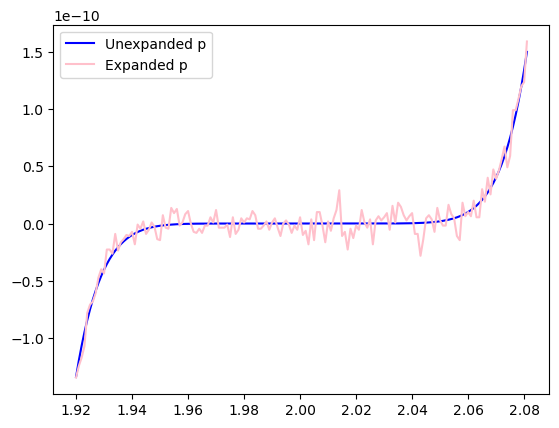

In [51]:
ff = f(x)
gg = g(x)

plt.plot(x, ff, color = 'blue', label = 'Unexpanded p')
plt.plot(x, gg, color = 'pink', label = 'Expanded p')

plt.legend()

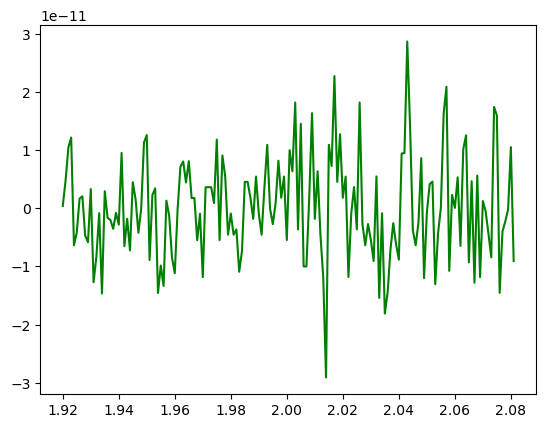

In [55]:
plt.plot(x, ff - gg, color = 'green', label = 'Difference')

In [101]:
from sympy import symbols, diff, sin
import inspect

In [103]:
def taylor(func, num):
    g = lambda x: func(x)
    f_exp = lambda x: func(x)
    for n in range(num):
        f_exp = lambda x: f_exp(x) + diff(g(x), x)
        g = lambda x: diff(g(x), x)
    print(inspect.getsource(f_exp))
    return f_exp
        

In [105]:
taylor(f, 1)

        f_exp = lambda x: f_exp(x) + diff(g(x), x)



<function __main__.taylor.<locals>.<lambda>(x)>

In [113]:
f = lambda x: ( x+1 ) ** (1/2) -1 



g = lambda x: x
h = lambda x: f(x)+g(x)
print(inspect.getsource(h))
h(1)

h = lambda x: f(x)+g(x)



1.4142135623730951

In [115]:
from sympy import *

def taylor(func, num):
    x = symbols('x')
    result = 0
    derivative = func

    for n in range(num):
        result += derivative / factorial(n) * x**n
        derivative = diff(derivative, x)

    return result

In [121]:
delta = np.logspace(-16, 0, 17)

f_norm = lambda x, y: math.cos(x-y) - math.cos(x)
f_exp = lambda x, y: -2*math.sin(x + (y / 2)) * math.sin( y / 2 )
f_tay = lambda x, y: y * math.sin( x ) - ( y ** 2 / 2) * math.cos(x)


# plt.plot(x, ff, color = 'blue', label = 'Unexpanded p')
# plt.plot(x, gg, color = 'pink', label = 'Expanded p')
# plt.plot(x, gg, color = 'green', label = 'Expanded p')

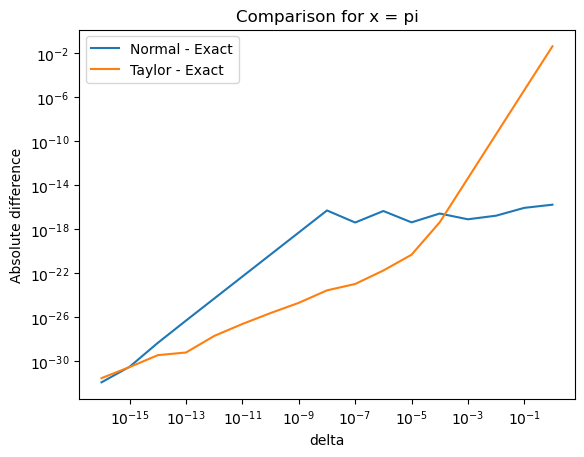

In [127]:
x = math.pi

normal = np.array([f_norm(x, d) for d in delta])
exact = np.array([f_exp(x, d) for d in delta])
tay = np.array([f_tay(x, d) for d in delta])

plt.figure()
plt.loglog(delta, abs(normal - exact), label='Normal - Exact')
plt.loglog(delta, abs(tay - exact), label='Taylor - Exact')

plt.xlabel('delta')
plt.ylabel('Absolute difference')
plt.title('Comparison for x = pi')
plt.legend()
plt.show()

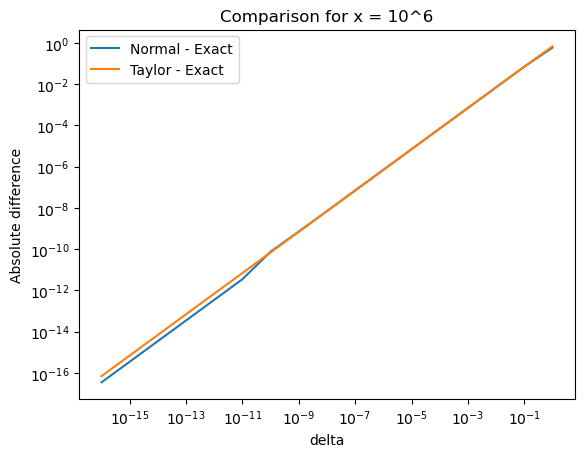

In [129]:
x = 10**6

normal = np.array([f_norm(x, d) for d in delta])
exact = np.array([f_exp(x, d) for d in delta])
tay = np.array([f_tay(x, d) for d in delta])

plt.figure()
plt.loglog(delta, abs(normal - exact), label='Normal - Exact')
plt.loglog(delta, abs(tay - exact), label='Taylor - Exact')

plt.xlabel('delta')
plt.ylabel('Absolute difference')
plt.title('Comparison for x = 10^6')
plt.legend()
plt.show()